# Lab 5

## Exercise 1: Calculating Distances with Functions

- Define a function `calculate_distance` that takes two geographic coordinates (latitude and longitude) and returns the distance between them using the Haversine formula.
- Use this function to calculate the distance between multiple pairs of coordinates.

In [1]:
from math import radians, sin, cos, sqrt, atan2

In [2]:
def calculate_distance(lat1, lon1, lat2, lon2):
  Radius_of_Earth = 6371
  d_lat = radians(lat2 - lat1)
  d_lon = radians(lon2 - lon1)
  a = sin(d_lat / 2) * sin(d_lat / 2) + cos(radians(lat1)) * cos(radians(lat2)) * sin(d_lon / 2) * sin(d_lon / 2)
  c = 2 * atan2(sqrt(a), sqrt(1 - a))
  return Radius_of_Earth * c


In [3]:
distance = calculate_distance(35.6895, 139.6917, 34.0522, -118.2437)
print(distance)

8815.473355809401


## Exercise 2: Batch Distance Calculation

- Create a function `batch_distance_calculation` that accepts a list of coordinate pairs and returns a list of distances between consecutive pairs.
- Test the function with a list of coordinates representing several cities.

In [4]:
def batch_distance_calculation(coordinates):
  distances = []
  for i in range(len(coordinates) - 1):
    lat1, lon1 = coordinates[i]
    lat2, lon2 = coordinates[i + 1]
    distance = calculate_distance(lat1, lon1, lat2, lon2)
    distances.append(distance)
  return distances

In [5]:
coordinates = [(35.6895, 139.6917), (34.0522, -118.2437), (48.8566, 2.3522)]
distances = batch_distance_calculation(coordinates)
print(distances)

[8815.473355809401, 9085.508815906822]


## Exercise 3: Creating and Using a Point Class

- Define a `Point` class to represent a geographic point with attributes `latitude`, `longitude`, and `name`.
- Add a method `distance_to` that calculates the distance from one point to another.
- Instantiate several `Point` objects and calculate the distance between them.

In [6]:
class Point:
  def __init__(self, latitude, longitude, name):
    self.latitude = latitude
    self.longitude = longitude
    self.name = name

  def distance_to(self, other):
    return calculate_distance(self.latitude, self.longitude, other.latitude, other.longitude)

In [8]:
Point1 = Point(35.6895, 139.6917, "Tokyo")
Point2 = Point(34.0522, -118.2437, "Los Angeles")
Point3 = Point(48.8566, 2.3522, "Paris")
Point4 = Point(51.5074, -0.1278, "London")
print(Point1.distance_to(Point2))
print(Point1.distance_to(Point3))
print(Point1.distance_to(Point4))

8815.473355809401
9712.071149483549
9558.713694955735


## Exercise 4: Reading and Writing Files

- Write a function `read_coordinates` that reads a file containing a list of coordinates (latitude, longitude) and returns them as a list of tuples.
- Write another function `write_coordinates` that takes a list of coordinates and writes them to a new file.
- Ensure that both functions handle exceptions, such as missing files or improperly formatted data.

In [10]:
def read_coordinates(file_path):
  coordinates = []
  try:
    with open(file_path, 'r') as file:
      for line in file:
        lat, lon = map(float, line.strip().split(','))
        coordinates.append
  except FileNotFoundError:
    print(f"File '{file_path}' not found.")
  except Exception as e:
    print(f"An error occurred: {e}")
  return coordinates

In [12]:
def write_coordinates(coordinates, output_file):
  try:
    with open(output_file, 'w') as file:
      for coord in coordinates:
        file.write(f"{coord[0]},{coord[1]}\n")
        print(f"Coordinates written to '{output_file}' successfully.")
  except Exception as e:
    print(f"An error occurred while writing to the file: {e}")
    return coordinates

## Exercise 5: Processing Coordinates from a File

- Create a function that reads coordinates from a file and uses the `Point` class to create `Point` objects.
- Calculate the distance between each consecutive pair of points and write the results to a new file.
- Ensure the function handles file-related exceptions and gracefully handles improperly formatted lines.

In [11]:
# Create a sample coordinates.txt file
sample_data = """35.6895,139.6917
34.0522,-118.2437
51.5074,-0.1278
-33.8688,151.2093
48.8566,2.3522"""

output_file = "coordinates.txt"

try:
    with open(output_file, "w") as file:
        file.write(sample_data)
    print(f"Sample file '{output_file}' has been created successfully.")
except Exception as e:
    print(f"An error occurred while creating the file: {e}")

Sample file 'coordinates.txt' has been created successfully.


In [13]:
def process_coordinates_from_file(input_file, output_file):
    points = []
    try:
        with open(input_file, 'r') as file:
            for line in file:
                try:
                    lat, lon = map(float, line.strip().split(','))
                    points.append(Point(lat, lon, ""))
                except ValueError:
                    print(f"Skipping invalid line: {line.strip()}")
    except FileNotFoundError:
        print(f"Input file '{input_file}' not found.")
        return

    distances = []
    for i in range(len(points) - 1):
        distances.append(points[i].distance_to(points[i+1]))

    try:
        with open(output_file, 'w') as file:
            for distance in distances:
                file.write(str(distance) + '\n')
        print(f"Distances written to '{output_file}' successfully.")
    except Exception as e:
        print(f"An error occurred while writing to the file: {e}")

process_coordinates_from_file("coordinates.txt", "distances.txt")


Distances written to 'distances.txt' successfully.


## Exercise 6: Exception Handling in Data Processing

- Modify the `batch_distance_calculation` function to handle exceptions that might occur during the calculation, such as invalid coordinates.
- Ensure the function skips invalid data and continues processing the remaining data.

In [14]:
from math import radians, sin, cos, sqrt, atan2

In [16]:
def batch_distance_calculation(coordinates):
    distances = []
    for i in range(len(coordinates) - 1):
        try:
            lat1, lon1 = coordinates[i]
            lat2, lon2 = coordinates[i + 1]

            if not (-90 <= lat1 <= 90 and -180 <= lon1 <= 180 and -90 <= lat2 <= 90 and -180 <= lon2 <= 180):
                print(f"Warning: Skipping invalid coordinates at index {i}: ({lat1}, {lon1}) and ({lat2}, {lon2})")
                continue

            distance = calculate_distance(lat1, lon1, lat2, lon2)
            distances.append(distance)
        except (ValueError, TypeError, IndexError) as e:
            print(f"Error processing coordinates at index {i}: {e}")

    return distances


## Exercise 7: NumPy Array Operations and Geospatial Coordinates

In this exercise, you will work with NumPy arrays representing geospatial coordinates (latitude and longitude) and perform basic array operations.

1. Create a 2D NumPy array containing the latitude and longitude of the following cities: Tokyo (35.6895, 139.6917), New York (40.7128, -74.0060), London (51.5074, -0.1278), and Paris (48.8566, 2.3522).
2. Convert the latitude and longitude values from degrees to radians using np.radians().
3. Calculate the element-wise difference between Tokyo and the other cities' latitude and longitude in radians.

In [17]:
import numpy as np

In [18]:
coordinates = np.array([
    [35.6895, 139.6917],
    [40.7128, -74.0060],
    [51.5074, -0.1278],
    [48.8566, 2.3522]
])

coordinates_rad = np.radians(coordinates)


tokyo_rad = coordinates_rad[0]
differences = coordinates_rad - tokyo_rad

differences


array([[ 0.        ,  0.        ],
       [ 0.08767312, -3.72972847],
       [ 0.27607444, -2.44031063],
       [ 0.22980925, -2.39702647]])

## Exercise 8: Pandas DataFrame Operations with Geospatial Data

In this exercise, you'll use Pandas to load and manipulate a dataset containing city population data, and then calculate and visualize statistics.

1. Load the world cities dataset from this URL using Pandas: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv
2. Display the first 5 rows and check for missing values.
3. Filter the dataset to only include cities with a population greater than 1 million.
4. Group the cities by their country and calculate the total population for each country.
5. Sort the cities by population in descending order and display the top 10 cities.

In [20]:
import pandas as pd

In [22]:
try:
    df_cities = pd.read_csv('https://github.com/opengeos/datasets/releases/download/world/world_cities.csv')

    print("First 5 rows of the dataset:")
    print(df_cities.head())


    print("\nMissing values in the dataset:")
    print(df_cities.isnull().sum())

    df_filtered = df_cities[df_cities['population'] > 1000000]
    print("\nCities with population > 1 million:")
    print(df_filtered.head())

    df_grouped = df_filtered.groupby('country')['population'].sum()
    print("\nTotal population by country:")
    print(df_grouped.head())

    df_sorted = df_cities.sort_values('population', ascending=False)
    print("\nTop 10 cities by population:")
    print(df_sorted.head(10))
except Exception as e:
    print(f"An error occurred: {e}")


First 5 rows of the dataset:
   id         name country  latitude  longitude  population
0   1        Bombo     UGA    0.5833    32.5333       75000
1   2  Fort Portal     UGA    0.6710    30.2750       42670
2   3      Potenza     ITA   40.6420    15.7990       69060
3   4   Campobasso     ITA   41.5630    14.6560       50762
4   5        Aosta     ITA   45.7370     7.3150       34062

Missing values in the dataset:
id            0
name          0
country       0
latitude      0
longitude     0
population    0
dtype: int64

Cities with population > 1 million:
      id            name country  latitude  longitude  population
97    98           Turin     ITA  45.07039    7.66996     1652000
103  104           Lille     FRA  50.64997    3.08001     1044000
123  124  San Bernardino     USA  34.12038 -117.30003     1745000
124  125      Bridgeport     USA  41.17998  -73.19996     1018000
126  127      Manchester     GBR  53.50042   -2.24799     2230000

Total population by country:
country

## Exercise 9: Creating and Manipulating GeoDataFrames with GeoPandas

This exercise focuses on creating and manipulating GeoDataFrames, performing spatial operations, and visualizing the data.

1. Load the New York City building dataset from the GeoJSON file using GeoPandas: https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson
2. Create a plot of the building footprints and color them based on the building height (use the `height_MS` column).
3. Create an interactive map of the building footprints and color them based on the building height (use the `height_MS` column).
4. Calculate the average building height (use the `height_MS` column).
5. Select buildings with a height greater than the average height.
6. Save the GeoDataFrame to a new GeoJSON file.

In [24]:
import pandas as pd
#!pip install geopandas
import geopandas as gpd
import matplotlib.pyplot as plt

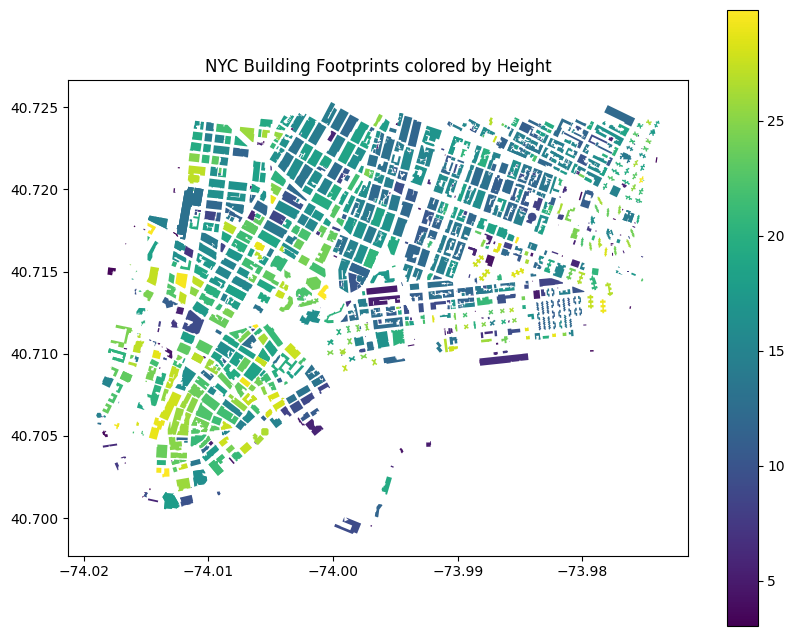

Average building height: 15.454691136974038
Tall buildings saved to tall_nyc_buildings.geojson


In [26]:
try:
    nyc_buildings = gpd.read_file('https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson')

    nyc_buildings.plot(column='height_MS', cmap='viridis', legend=True, figsize=(10, 8))
    plt.title('NYC Building Footprints colored by Height')
    plt.show()


    average_height = nyc_buildings['height_MS'].mean()
    print(f"Average building height: {average_height}")

    tall_buildings = nyc_buildings[nyc_buildings['height_MS'] > average_height]

    tall_buildings.to_file("tall_nyc_buildings.geojson", driver="GeoJSON")
    print("Tall buildings saved to tall_nyc_buildings.geojson")

except Exception as e:
    print(f"An error occurred: {e}")


## Exercise 10: Combining NumPy, Pandas, and GeoPandas

This exercise requires you to combine the power of NumPy, Pandas, and GeoPandas to analyze and visualize spatial data.

1. Use Pandas to load the world cities dataset from this URL: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv
2. Filter the dataset to include only cities with latitude values between -40 and 60 (i.e., cities located in the Northern Hemisphere or near the equator).
3. Create a GeoDataFrame from the filtered dataset by converting the latitude and longitude into geometries.
4. Reproject the GeoDataFrame to the Mercator projection (EPSG:3857).
5. Calculate the distance (in meters) between each city and the city of Paris.
6. Plot the cities on a world map, coloring the points by their distance from Paris.

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from pyproj import CRS

In [28]:
try:
    # Load the world cities dataset
    df_cities = pd.read_csv('https://github.com/opengeos/datasets/releases/download/world/world_cities.csv')

    # Filter cities by latitude
    df_filtered = df_cities[(df_cities['lat'] >= -40) & (df_cities['lat'] <= 60)]

    # Create a GeoDataFrame
    geometry = [Point(xy) for xy in zip(df_filtered['lng'], df_filtered['lat'])]
    gdf_cities = gpd.GeoDataFrame(df_filtered, geometry=geometry, crs="EPSG:4326")

    # Reproject to Mercator
    gdf_cities_mercator = gdf_cities.to_crs(epsg=3857)

    # Find Paris
    paris = gdf_cities_mercator[gdf_cities_mercator['city'] == 'Paris']
    if paris.empty:
        raise ValueError("Paris not found in the dataset.")
    paris_geometry = paris.geometry.iloc[0]

    # Calculate distances from Paris
    gdf_cities_mercator['distance_from_paris'] = gdf_cities_mercator.distance(paris_geometry)

    # Plot the cities
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    ax = world.plot(color='lightgrey', edgecolor='white', figsize=(15, 10))
    gdf_cities_mercator.plot(ax=ax, column='distance_from_paris', cmap='viridis', legend=True, markersize=10)

    # Customize the plot (optional)
    ax.set_title('Cities and their distance from Paris')
    ax.set_axis_off()
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")


An error occurred: 'lat'


## Submission Requirements

Complete the exercises above and and upload the notebook to your GitHub repository. Make sure the notebook has a Colab badge at the top so that it can be easily opened in Google Colab. Submit the URL of the notebook to Canvas.